# LAB 06: NHẬN DIỆN ẢNH (IMAGE DETECTION)

Sử dụng Haar Cascade Classifier để nhận diện đối tượng trong ảnh.


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


## Nhận diện biển báo STOP 

Sử dụng `stop_data.xml` để phát hiện biển STOP trong ảnh.


Số biển STOP tìm thấy: 1


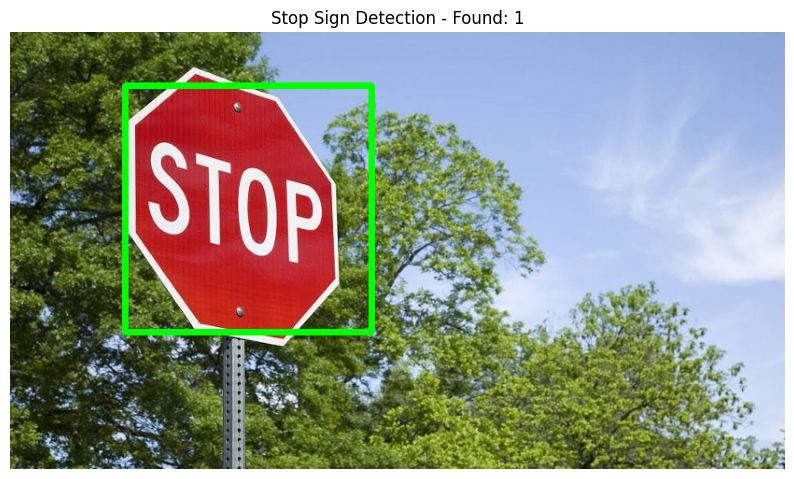

In [2]:
# Đọc ảnh biển STOP
img = cv2.imread("stop_sign.png")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load Haar Cascade cho Stop Sign
stop_data = cv2.CascadeClassifier('stop_data.xml')

# Detect
found = stop_data.detectMultiScale(img_gray, minSize=(20, 20))
amount_found = len(found)
print(f"Số biển STOP tìm thấy: {amount_found}")

if amount_found != 0:
    for (x, y, width, height) in found:
        cv2.rectangle(img_rgb, (x, y),
                      (x + height, y + width),
                      (0, 255, 0), 5)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title(f'Stop Sign Detection - Found: {amount_found}')
plt.axis('off')
plt.show()


## Phần 1: Nhận diện khuôn mặt

Sử dụng `haarcascade_frontalface_default.xml` để nhận diện khuôn mặt trong ảnh.

File XML được tải từ: https://github.com/kipr/opencv/tree/master/data/haarcascades


Số khuôn mặt tìm thấy: 3


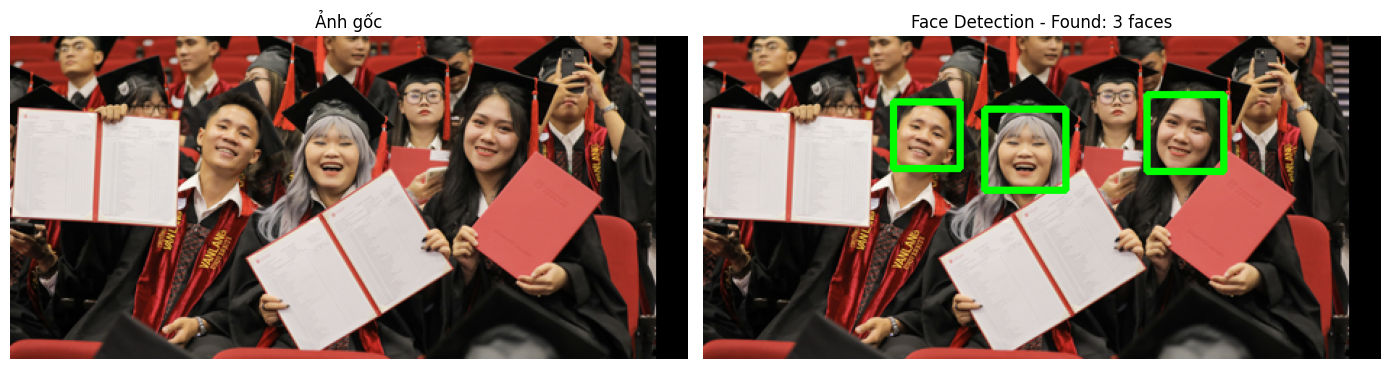

In [3]:
# Đọc ảnh có khuôn mặt
img_face = cv2.imread("image.png")
img_face_gray = cv2.cvtColor(img_face, cv2.COLOR_BGR2GRAY)
img_face_rgb = cv2.cvtColor(img_face, cv2.COLOR_BGR2RGB)

# Load Haar Cascade cho Face Detection
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Detect faces
faces = face_cascade.detectMultiScale(
    img_face_gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print(f"Số khuôn mặt tìm thấy: {len(faces)}")

# Vẽ hình chữ nhật quanh khuôn mặt
img_result = img_face_rgb.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(img_result, (x, y), (x + w, y + h), (0, 255, 0), 3)

# Hiển thị
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_face_rgb)
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_result)
plt.title(f'Face Detection - Found: {len(faces)} faces')
plt.axis('off')

plt.tight_layout()
plt.show()


### Thử nghiệm các tham số khác nhau

- `scaleFactor`: hệ số thu nhỏ ảnh ở mỗi scale (1.05 = chậm nhưng chính xác hơn)
- `minNeighbors`: số lượng neighbor tối thiểu để giữ detection (cao = ít false positive)
- `minSize`: kích thước tối thiểu của đối tượng


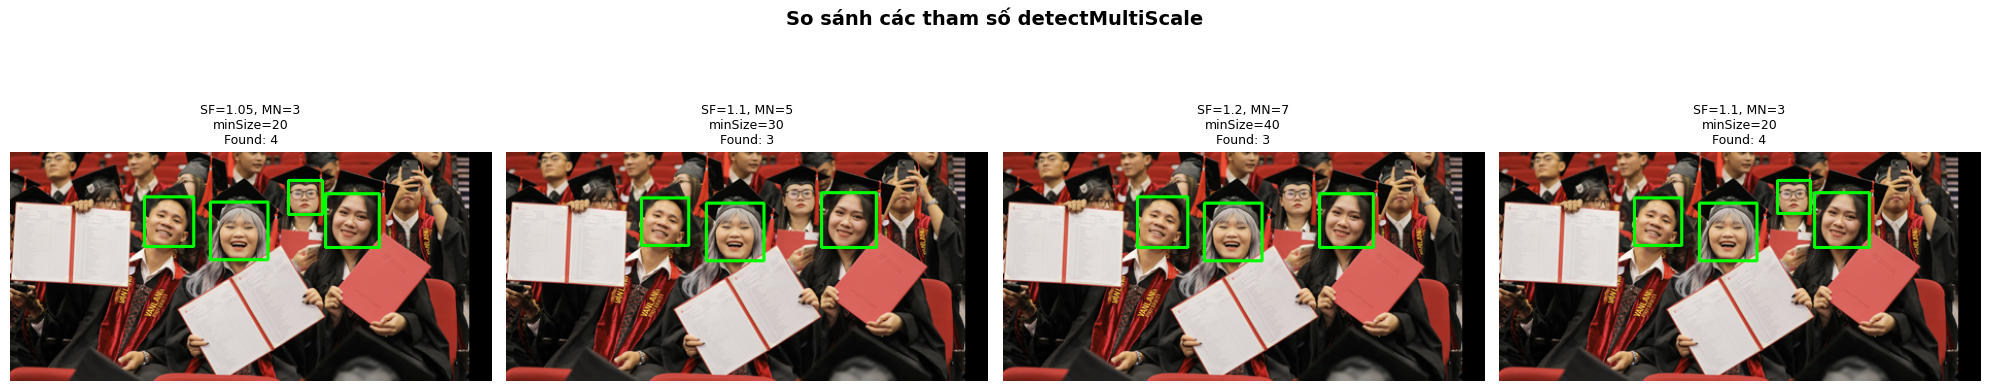

In [4]:
# Thử nghiệm với các tham số khác nhau
params = [
    {"scaleFactor": 1.05, "minNeighbors": 3, "minSize": (20, 20)},
    {"scaleFactor": 1.1, "minNeighbors": 5, "minSize": (30, 30)},
    {"scaleFactor": 1.2, "minNeighbors": 7, "minSize": (40, 40)},
    {"scaleFactor": 1.1, "minNeighbors": 3, "minSize": (20, 20)},
]

fig, axes = plt.subplots(1, len(params), figsize=(20, 5))

for i, p in enumerate(params):
    faces_p = face_cascade.detectMultiScale(
        img_face_gray,
        scaleFactor=p["scaleFactor"],
        minNeighbors=p["minNeighbors"],
        minSize=p["minSize"]
    )
    img_temp = img_face_rgb.copy()
    for (x, y, w, h) in faces_p:
        cv2.rectangle(img_temp, (x, y), (x + w, y + h), (0, 255, 0), 2)
    axes[i].imshow(img_temp)
    axes[i].set_title(f'SF={p["scaleFactor"]}, MN={p["minNeighbors"]}\nminSize={p["minSize"][0]}\nFound: {len(faces_p)}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('So sánh các tham số detectMultiScale', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Cắt và hiển thị từng khuôn mặt


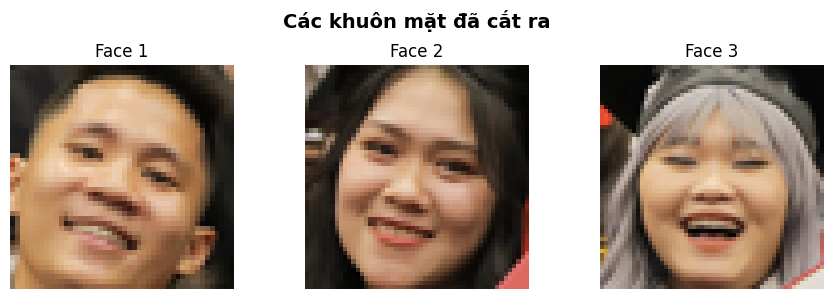

In [5]:
# Cắt từng khuôn mặt đã detect được
faces_best = face_cascade.detectMultiScale(img_face_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

if len(faces_best) > 0:
    n_faces = min(len(faces_best), 10)  # Hiển thị tối đa 10 khuôn mặt
    fig, axes = plt.subplots(1, n_faces, figsize=(3 * n_faces, 3))
    if n_faces == 1:
        axes = [axes]
    for i in range(n_faces):
        x, y, w, h = faces_best[i]
        face_crop = img_face_rgb[y:y+h, x:x+w]
        axes[i].imshow(face_crop)
        axes[i].set_title(f'Face {i+1}')
        axes[i].axis('off')
    plt.suptitle('Các khuôn mặt đã cắt ra', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy khuôn mặt nào!")
